# Paper download via OpenAlex / Unpaywall (Sci-Hub bypass, step 1)

This notebook is a first exploration of an alternative to the Sci-Hub based download in `src/copolextractor/doi2pdf.py`.
It does **not** replace the existing download pipeline yet, it only measures how far we get without Sci-Hub:

0. Restrict the paper list to those Sci-Hub was previously able to download (`"downloaded": true`) — these are the only ones that matter here.
1. Count how many of those papers are published by Nature / Elsevier (these are ignored for now, since they rarely provide open-access PDFs).
2. For all remaining papers, try to resolve an open-access PDF URL via the OpenAlex and Unpaywall APIs and download it.
3. Report how many papers are still missing afterwards.

If this approach turns out to work well, the logic can be merged into `PDF_download.py` / `doi2pdf.py` later.

In [7]:
import json
import os
import time
from collections import Counter
from pathlib import Path

import requests
from dotenv import load_dotenv

# Loads secrets (e.g. CORE_API_KEY) from a local .env file next to this notebook; never commit that file.
load_dotenv(Path.cwd() / ".env")

# Use the merged list so the complete Sci-Hub-downloadable set is analyzed.
INPUT_JSON = Path("../artifacts/metadata/output/selected_papers_merged.json")

# Folder the successfully downloaded PDFs are written to.
OUTPUT_PDF_DIR = Path("../artifacts/metadata/output/PDF_openalex_unpaywall")

# Unpaywall requires a contact email for every request (its "polite pool" policy).
UNPAYWALL_EMAIL = "mara.wilhelmi@uni-jena.de"

REQUEST_TIMEOUT_SECONDS = 20
OUTPUT_PDF_DIR.mkdir(parents=True, exist_ok=True)

SLEEP_BETWEEN_REQUESTS_SECONDS = 0.2

In [8]:
def load_papers(input_json: Path) -> list[dict]:
    """Load the list of paper metadata dicts from the given JSON file."""
    with open(input_json, "r", encoding="utf-8") as f:
        return json.load(f)


def normalize_doi(doi: str) -> str:
    """Strip a leading DOI URL prefix, if present, and surrounding whitespace."""
    doi = doi.strip()
    for prefix in ("https://doi.org/", "http://doi.org/", "doi:"):
        if doi.startswith(prefix):
            doi = doi[len(prefix):]
    return doi


papers = load_papers(INPUT_JSON)
print(f"Loaded {len(papers)} papers from {INPUT_JSON}")

# Only papers Sci-Hub was previously able to provide a PDF for are relevant here.
papers = [p for p in papers if p.get("downloaded") is True]
print(f"Of those, {len(papers)} were successfully downloaded via Sci-Hub before")

Loaded 1989 papers from ../artifacts/metadata/output/selected_papers_merged.json
Of those, 1851 were successfully downloaded via Sci-Hub before


## Publisher overview of all Sci-Hub-downloaded papers

Live look-up of the real publisher name per DOI via the Crossref API (`api.crossref.org/works/{doi}`), which is more reliable than guessing from the DOI prefix.

In [9]:
def get_publisher_name_from_crossref(doi: str) -> str | None:
    """Return the publisher name for the DOI from the Crossref API, or None if the lookup fails."""
    url = f"https://api.crossref.org/works/{doi}"
    try:
        response = requests.get(url, params={"mailto": UNPAYWALL_EMAIL}, timeout=REQUEST_TIMEOUT_SECONDS)
        response.raise_for_status()
    except requests.exceptions.RequestException:
        return None

    return (response.json().get("message") or {}).get("publisher")


papers_with_doi_all = [p for p in papers if p.get("DOI", "").strip()]

publisher_by_doi = {}
for index, paper in enumerate(papers_with_doi_all, start=1):
    doi = normalize_doi(paper["DOI"])
    print(f"[{index}/{len(papers_with_doi_all)}] looking up publisher for {doi}")
    publisher_by_doi[doi] = get_publisher_name_from_crossref(doi) or "unknown"
    time.sleep(SLEEP_BETWEEN_REQUESTS_SECONDS)

publisher_name_counts = Counter(publisher_by_doi.values())

print(f"Publisher breakdown of all {len(papers_with_doi_all)} Sci-Hub-downloaded papers with a DOI:")
for publisher_name, count in publisher_name_counts.most_common():
    print(f"  - {publisher_name}: {count}")

[1/1851] looking up publisher for 10.1016/s0032-3861(01)00697-8
[2/1851] looking up publisher for 10.1016/0168-7336(89)80086-5
[3/1851] looking up publisher for 10.1016/0168-7336(88)80036-6
[4/1851] looking up publisher for 10.1016/0168-7336(89)80019-1
[5/1851] looking up publisher for 10.1016/0168-7336(89)80034-8
[6/1851] looking up publisher for 10.1016/0014-3057(95)00157-3
[7/1851] looking up publisher for 10.1016/0168-7336(88)80094-9
[8/1851] looking up publisher for 10.1016/0168-7336(89)80050-6
[9/1851] looking up publisher for 10.1016/0168-7336(88)80077-9
[10/1851] looking up publisher for 10.1007/s10965-008-9230-2
[11/1851] looking up publisher for 10.1021/acs.iecr.9b06413.s001
[12/1851] looking up publisher for 10.1016/s0014-3057(96)00270-4
[13/1851] looking up publisher for 10.1016/0168-7336(88)80053-6
[14/1851] looking up publisher for 10.1246/nikkashi1898.74.9_1913
[15/1851] looking up publisher for 10.1002/marc.200700875
[16/1851] looking up publisher for 10.1080/1060132670

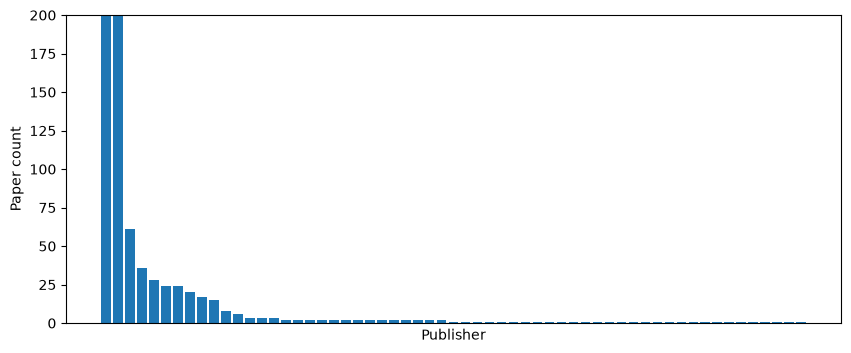

In [ ]:
import matplotlib.pyplot as plt

all_counts_sorted = [count for _, count in publisher_name_counts.most_common()]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(all_counts_sorted)), all_counts_sorted)
ax.set_xlabel("Publisher")
ax.set_ylabel("Paper count")
ax.set_ylim(top=200)
ax.set_xticks([])
plt.show()

In [ ]:
print("DOIs of all papers successfully downloaded via Sci-Hub:")
for paper in papers_with_doi_all:
    print(normalize_doi(paper["DOI"]))

In [ ]:
# A publisher with only a handful of papers barely shows up as a bar; this quantifies that long tail.
LONG_TAIL_MAX_COUNT = 2

long_tail_publishers = [name for name, count in publisher_name_counts.items() if count <= LONG_TAIL_MAX_COUNT]
long_tail_paper_count = sum(publisher_name_counts[name] for name in long_tail_publishers)

print(f"Publishers with <= {LONG_TAIL_MAX_COUNT} papers: {len(long_tail_publishers)}")
print(f"Papers hidden in that long tail: {long_tail_paper_count} of {sum(all_counts_sorted)}")

## Step 1: count Nature / Elsevier papers

Publisher is derived from the DOI prefix, which is a fast, offline-only heuristic (no API calls needed):
- Elsevier DOIs start with `10.1016`
- Nature Publishing Group / Springer Nature DOIs start with `10.1038`

In [ ]:
ELSEVIER_DOI_PREFIX = "10.1016"
NATURE_DOI_PREFIXES = ("10.1038",)


def classify_publisher(doi: str) -> str:
    """Classify a DOI as "elsevier", "nature" or "other" based on its registrant prefix."""
    doi = normalize_doi(doi)
    if doi.startswith(ELSEVIER_DOI_PREFIX):
        return "elsevier"
    if doi.startswith(NATURE_DOI_PREFIXES):
        return "nature"
    return "other"


papers_with_doi = [p for p in papers if p.get("DOI", "").strip()]
publisher_counts = Counter(classify_publisher(p["DOI"]) for p in papers_with_doi)

ignored_papers = [p for p in papers_with_doi if classify_publisher(p["DOI"]) in ("elsevier", "nature")]
candidate_papers = [p for p in papers_with_doi if classify_publisher(p["DOI"]) == "other"]

print(f"Total papers with a DOI: {len(papers_with_doi)}")
print(f"  - Elsevier (ignored):  {publisher_counts['elsevier']}")
print(f"  - Nature (ignored):    {publisher_counts['nature']}")
print(f"  - Other (candidates):  {publisher_counts['other']}")

Sci-Hub-downloaded papers with a DOI: 1497
  - Elsevier (ignored):  207
  - Nature (ignored):    7
  - Other (candidates):  1283


## Step 2: resolve open-access PDF URLs via OpenAlex, Unpaywall, Semantic Scholar and CORE

The APIs are tried in this order, from most to least likely to cover our (mostly older) papers:
1. **OpenAlex** – broadest metadata coverage, aggregates many sources itself.
2. **Unpaywall** – strong for older papers via green/repository OA copies.
3. **Semantic Scholar** – good general coverage, no API key required.
4. **CORE** – aggregates repositories, often has older papers too, but requires a free API key (`CORE_API_KEY`); skipped automatically if no key is set.

In [ ]:
def get_openalex_pdf_url(doi: str) -> str | None:
    """Return an open-access PDF URL for the DOI from OpenAlex, or None if not available."""
    url = f"https://api.openalex.org/works/https://doi.org/{doi}"
    try:
        response = requests.get(url, params={"mailto": UNPAYWALL_EMAIL}, timeout=REQUEST_TIMEOUT_SECONDS)
        response.raise_for_status()
    except requests.exceptions.RequestException:
        return None

    metadata = response.json()
    best_oa_location = metadata.get("best_oa_location") or {}
    if best_oa_location.get("pdf_url"):
        return best_oa_location["pdf_url"]

    open_access = metadata.get("open_access") or {}
    return open_access.get("oa_url")


def get_unpaywall_pdf_url(doi: str) -> str | None:
    """Return an open-access PDF URL for the DOI from Unpaywall, or None if not available."""
    url = f"https://api.unpaywall.org/v2/{doi}"
    try:
        response = requests.get(url, params={"email": UNPAYWALL_EMAIL}, timeout=REQUEST_TIMEOUT_SECONDS)
        response.raise_for_status()
    except requests.exceptions.RequestException:
        return None

    metadata = response.json()
    best_oa_location = metadata.get("best_oa_location") or {}
    if best_oa_location.get("url_for_pdf"):
        return best_oa_location["url_for_pdf"]
    return best_oa_location.get("url")


def download_pdf(pdf_url: str) -> bytes | None:
    """Download the PDF from the given URL and return its bytes, or None if it is not a valid PDF."""
    headers = {"User-Agent": "Mozilla/5.0 (compatible; copolextractor/1.0)"}
    try:
        response = requests.get(pdf_url, headers=headers, timeout=REQUEST_TIMEOUT_SECONDS)
        response.raise_for_status()
    except requests.exceptions.RequestException:
        return None

    if not response.content.startswith(b"%PDF"):
        return None
    return response.content

In [ ]:
def sanitize_doi_for_filename(doi: str) -> str:
    """Turn a DOI into a filesystem-safe file name stem."""
    return doi.replace("/", "_").replace("\\", "_")


results = {"downloaded": [], "no_oa_url": [], "download_failed": []}
# Records which resolver actually provided the PDF URL for each downloaded DOI.
download_source = {}

for index, paper in enumerate(candidate_papers, start=1):
    doi = normalize_doi(paper["DOI"])
    output_path = OUTPUT_PDF_DIR / f"{sanitize_doi_for_filename(doi)}.pdf"

    if output_path.exists():
        results["downloaded"].append(doi)
        continue

    print(f"[{index}/{len(candidate_papers)}] {doi}")

    pdf_url = get_openalex_pdf_url(doi)
    source = "openalex"
    time.sleep(SLEEP_BETWEEN_REQUESTS_SECONDS)
    if not pdf_url:
        pdf_url = get_unpaywall_pdf_url(doi)
        source = "unpaywall"
        time.sleep(SLEEP_BETWEEN_REQUESTS_SECONDS)

    if not pdf_url:
        print("  no open-access URL found")
        results["no_oa_url"].append(doi)
        continue

    pdf_content = download_pdf(pdf_url)
    if pdf_content is None:
        print(f"  found URL but download failed: {pdf_url}")
        results["download_failed"].append(doi)
        continue

    download_source[doi] = source

    output_path.write_bytes(pdf_content)
    results["downloaded"].append(doi)
    print(f"  downloaded -> {output_path}")

[1/1283] 10.1007/s10965-008-9230-2
  no open-access URL found
[2/1283] 10.1021/acs.iecr.9b06413.s001
  found URL but download failed: https://figshare.com/articles/Reactivity_Ratios_of_MMA_and_i_N_i_i_N_i_Dimethyl_i_N_i_2-_2-methylprop-2-enoyl_oxy_ethyl_undecane-1-aminium_Bromide_in_Thermal_and_UV_Initiation_Copolymerization/12207986
[3/1283] 10.1246/nikkashi1898.74.9_1913
  downloaded -> ../artifacts/metadata/output/PDF_openalex_unpaywall/10.1246_nikkashi1898.74.9_1913.pdf
[4/1283] 10.1002/marc.200700875
  no open-access URL found
[5/1283] 10.1080/10601326708053986
  no open-access URL found
[6/1283] 10.1002/pol.1983.170210821
  no open-access URL found
[7/1283] 10.1246/nikkashi1898.69.5_986
  downloaded -> ../artifacts/metadata/output/PDF_openalex_unpaywall/10.1246_nikkashi1898.69.5_986.pdf
[8/1283] 10.1002/macp.201200165
  no open-access URL found
[9/1283] 10.1002/app.12104
  no open-access URL found
[10/1283] 10.14314/polimery.2004.356
  found URL but download failed: https://doi.o

## Step 3: summary — how many papers are still missing?

In [ ]:
still_missing_after_retry = []

for index, doi in enumerate(still_missing, start=1):
    output_path = OUTPUT_PDF_DIR / f"{sanitize_doi_for_filename(doi)}.pdf"

    print(f"[{index}/{len(still_missing)}] retrying {doi}")

    pdf_url = get_semantic_scholar_pdf_url(doi)
    source = "semantic_scholar"
    time.sleep(SLEEP_BETWEEN_REQUESTS_SECONDS)
    if not pdf_url:
        pdf_url = get_core_pdf_url(doi)
        source = "core"
        time.sleep(SLEEP_BETWEEN_REQUESTS_SECONDS)

    if not pdf_url:
        print("  no open-access URL found")
        still_missing_after_retry.append(doi)
        continue

    pdf_content = download_pdf(pdf_url)
    if pdf_content is None:
        print(f"  found URL but download failed: {pdf_url}")
        still_missing_after_retry.append(doi)
        continue

    output_path.write_bytes(pdf_content)
    print(f"  downloaded -> {output_path}")
    results["downloaded"].append(doi)
    download_source[doi] = source

print(f"Additionally downloaded via Semantic Scholar/CORE: {len(still_missing) - len(still_missing_after_retry)}")
print(f"Still missing after all sources: {len(still_missing_after_retry)}")

missing_dois_path = OUTPUT_PDF_DIR / "still_missing_dois.json"
with open(missing_dois_path, "w", encoding="utf-8") as f:
    json.dump(still_missing_after_retry, f, indent=2)

print(f"Updated {missing_dois_path} with {len(still_missing_after_retry)} remaining DOIs")

Sci-Hub-downloaded papers with a DOI: 1497
Ignored (Nature + Elsevier):     214
Candidates tried (other):        1283
  - downloaded via OpenAlex/Unpaywall: 48
  - no open-access URL found:          1116
  - URL found but download failed:     119
Still missing (need Sci-Hub or manual): 1235


In [ ]:
# Persist the DOIs that still need another download strategy (e.g. Sci-Hub) for later steps.
missing_dois_path = OUTPUT_PDF_DIR / "still_missing_dois.json"
with open(missing_dois_path, "w", encoding="utf-8") as f:
    json.dump(still_missing, f, indent=2)

print(f"Saved {len(still_missing)} still-missing DOIs to {missing_dois_path}")

Saved 1235 still-missing DOIs to ../artifacts/metadata/output/PDF_openalex_unpaywall/still_missing_dois.json


## Step 4: further download attempts via Semantic Scholar and CORE

For the DOIs that are still missing after Step 3, try two more open-access sources:
- **Semantic Scholar** – good general coverage, no API key required.
- **CORE** – aggregates repositories, requires a free API key (`CORE_API_KEY`); skipped automatically if no key is set.

In [ ]:
def get_semantic_scholar_pdf_url(doi: str) -> str | None:
    """Return an open-access PDF URL for the DOI from Semantic Scholar, or None if not available."""
    url = f"https://api.semanticscholar.org/graph/v1/paper/DOI:{doi}"
    try:
        response = requests.get(url, params={"fields": "openAccessPdf"}, timeout=REQUEST_TIMEOUT_SECONDS)
        response.raise_for_status()
    except requests.exceptions.RequestException:
        return None

    metadata = response.json()
    open_access_pdf = metadata.get("openAccessPdf") or {}
    return open_access_pdf.get("url")


# API key is loaded from the local .env file (CORE_API_KEY=...); this fallback is skipped if unset.
CORE_API_KEY = os.environ.get("CORE_API_KEY", "")


def get_core_pdf_url(doi: str) -> str | None:
    """Return an open-access PDF URL for the DOI from CORE, or None if not available or no API key is set."""
    if not CORE_API_KEY:
        return None

    url = "https://api.core.ac.uk/v3/search/works"
    headers = {"Authorization": f"Bearer {CORE_API_KEY}"}
    try:
        response = requests.post(
            url, headers=headers, json={"q": f'doi:"{doi}"'}, timeout=REQUEST_TIMEOUT_SECONDS
        )
        response.raise_for_status()
    except requests.exceptions.RequestException:
        return None

    results = (response.json() or {}).get("results") or []
    if not results:
        return None
    return results[0].get("downloadUrl")

In [ ]:
still_missing_after_retry = []

for index, doi in enumerate(still_missing, start=1):
    output_path = OUTPUT_PDF_DIR / f"{sanitize_doi_for_filename(doi)}.pdf"

    print(f"[{index}/{len(still_missing)}] retrying {doi}")

    pdf_url = get_semantic_scholar_pdf_url(doi)
    source = "semantic_scholar"
    time.sleep(SLEEP_BETWEEN_REQUESTS_SECONDS)
    if not pdf_url:
        pdf_url = get_core_pdf_url(doi)
        source = "core"
        time.sleep(SLEEP_BETWEEN_REQUESTS_SECONDS)

    if not pdf_url:
        print("  no open-access URL found")
        still_missing_after_retry.append(doi)
        continue

    pdf_content = download_pdf(pdf_url)
    if pdf_content is None:
        print(f"  found URL but download failed: {pdf_url}")
        still_missing_after_retry.append(doi)
        continue

    output_path.write_bytes(pdf_content)
    print(f"  downloaded -> {output_path}")
    results["downloaded"].append(doi)
    download_source[doi] = source

print(f"Additionally downloaded via Semantic Scholar/CORE: {len(still_missing) - len(still_missing_after_retry)}")
print(f"Still missing after all sources: {len(still_missing_after_retry)}")

missing_dois_path = OUTPUT_PDF_DIR / "still_missing_dois.json"
with open(missing_dois_path, "w", encoding="utf-8") as f:

    json.dump(still_missing_after_retry, f, indent=2)

print(f"Updated {missing_dois_path} with {len(still_missing_after_retry)} remaining DOIs")


[1/1235] retrying 10.1007/s10965-008-9230-2
  no open-access URL found
[2/1235] retrying 10.1002/marc.200700875
  found URL but download failed: https://core.ac.uk/download/359845634.pdf
[3/1235] retrying 10.1080/10601326708053986
  no open-access URL found
[4/1235] retrying 10.1002/pol.1983.170210821
  no open-access URL found
[5/1235] retrying 10.1002/macp.201200165
  found URL but download failed: https://core.ac.uk/download/391606358.pdf
[6/1235] retrying 10.1002/app.12104
  no open-access URL found
[7/1235] retrying 10.1080/00222337008069362
  no open-access URL found
[8/1235] retrying 10.1002/app.37644
  found URL but download failed: https://core.ac.uk/download/391319042.pdf
[9/1235] retrying 10.1002/app.22338
  no open-access URL found
[10/1235] retrying 10.1002/mats.200390014
  found URL but download failed: https://core.ac.uk/download/372784962.pdf
[11/1235] retrying 10.1080/15321797008068151
  no open-access URL found
[12/1235] retrying 10.1002/app.28099
  no open-access URL

## Step 5: final breakdown — downloaded vs. still missing

In [ ]:
print(f"Candidates tried in total:        {len(candidate_papers)}")
print(f"Downloaded successfully:           {len(results['downloaded'])}")
print(f"Still missing after all sources:   {len(still_missing_after_retry)}")
print(f"  - no open-access URL found:      {len(results['no_oa_url'])}")
print(f"  - URL found but download failed: {len(results['download_failed'])}")

Candidates tried in total:        1283
Downloaded successfully:           52
Still missing after all sources:   1231
  - no open-access URL found:      1116
  - URL found but download failed: 119


## Step 6: publisher breakdown of the still-missing papers

In [ ]:
still_missing_publisher_counts = Counter(
    publisher_by_doi.get(doi, "unknown") for doi in still_missing_after_retry
)

print(f"Publisher breakdown of the {len(still_missing_after_retry)} still-missing papers:")
for publisher_name, count in still_missing_publisher_counts.most_common():
    print(f"  - {publisher_name}: {count}")

Publisher breakdown of the 1231 still-missing papers:
  - Wiley: 974
  - American Chemical Society (ACS): 60
  - MDPI AG: 36
  - Oxford University Press (OUP): 24
  - Informa UK Limited: 20
  - Walter de Gruyter GmbH: 17
  - Springer Science and Business Media LLC: 16
  - Royal Society of Chemistry (RSC): 15
  - Rubber Division, ACS: 8
  - AIP Publishing: 5
  - SAGE Publications: 3
  - Trans Tech Publications, Ltd.: 3
  - Springer US: 2
  - Institute of Organic Chemistry & Biochemistry: 2
  - Springer Netherlands: 2
  - CRC Press: 2
  - CSIRO Publishing: 2
  - SAE International: 2
  - Springer-Verlag: 2
  - American Psychological Association (APA): 2
  - Ovid Technologies (Wolters Kluwer Health): 2
  - China Science Publishing & Media Ltd.: 2
  - IOP Publishing: 2
  - Office of Scientific and Technical Information (OSTI): 2
  - Emerald: 1
  - The Royal Society: 1
  - Federal Research Center for Information and Computational Technologies: 1
  - Austrian Science Fund (FWF): 1
  - Pleiade

In [ ]:
# A publisher with only a handful of papers barely shows up as a bar; this quantifies that long tail.
LONG_TAIL_MAX_COUNT = 10

still_missing_long_tail_publishers = [
    name for name, count in still_missing_publisher_counts.items() if count <= LONG_TAIL_MAX_COUNT
]
still_missing_long_tail_paper_count = sum(
    still_missing_publisher_counts[name] for name in still_missing_long_tail_publishers
)

print(f"Publishers with <= {LONG_TAIL_MAX_COUNT} still-missing papers: {len(still_missing_long_tail_publishers)}")
print(f"Still-missing papers hidden in that long tail: {still_missing_long_tail_paper_count} of {sum(counts_sorted)}")

Publishers with <= 10 still-missing papers: 42
Still-missing papers hidden in that long tail: 69 of 1231


Matplotlib is building the font cache; this may take a moment.


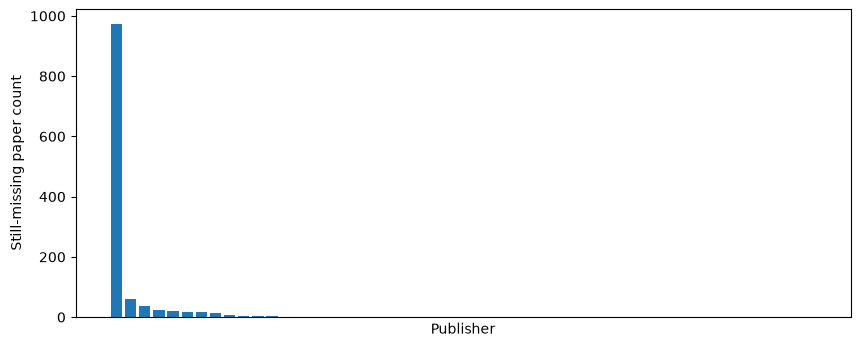

In [ ]:
import matplotlib.pyplot as plt

counts_sorted = [count for _, count in still_missing_publisher_counts.most_common()]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(counts_sorted)), counts_sorted)
ax.set_xlabel("Publisher")
ax.set_ylabel("Still-missing paper count")
ax.set_ylim(top=200)
ax.set_xticks([])
plt.show()

In [4]:
print("DOIs of all papers successfully downloaded via Sci-Hub:")
for paper in papers_with_doi_all:
    print(normalize_doi(paper["DOI"]))

DOIs of all papers successfully downloaded via Sci-Hub:
10.1016/s0032-3861(01)00697-8
10.1016/0168-7336(89)80086-5
10.1016/0168-7336(88)80036-6
10.1016/0168-7336(89)80019-1
10.1016/0168-7336(89)80034-8
10.1016/0014-3057(95)00157-3
10.1016/0168-7336(88)80094-9
10.1016/0168-7336(89)80050-6
10.1016/0168-7336(88)80077-9
10.1007/s10965-008-9230-2
10.1021/acs.iecr.9b06413.s001
10.1016/s0014-3057(96)00270-4
10.1016/0168-7336(88)80053-6
10.1246/nikkashi1898.74.9_1913
10.1002/marc.200700875
10.1080/10601326708053986
10.1002/pol.1983.170210821
10.1246/nikkashi1898.69.5_986
10.1002/macp.201200165
10.1016/0032-3861(93)90297-n
10.1002/app.12104
10.14314/polimery.2004.356
10.1080/00222337008069362
10.1016/s0014-3057(99)00230-x
10.1016/s1381-5148(03)00028-2
10.1002/app.37644
10.1016/0014-3057(91)90103-u
10.1002/app.22338
10.1002/mats.200390014
10.1080/15321797008068151
10.1295/polymj.3.670
10.1002/app.28099
10.1002/app.21873
10.1295/polymj.14.705
10.1002/app.24065
10.1002/pola.20874
10.1007/s10965-00

In [10]:
doi_list = [normalize_doi(paper["DOI"]) for paper in papers_with_doi_all]

print(f"DOIs 1-500 of {len(doi_list)}:")
for doi in doi_list[:500]:
    print(doi)

DOIs 1-500 of 1851:
10.1016/s0032-3861(01)00697-8
10.1016/0168-7336(89)80086-5
10.1016/0168-7336(88)80036-6
10.1016/0168-7336(89)80019-1
10.1016/0168-7336(89)80034-8
10.1016/0014-3057(95)00157-3
10.1016/0168-7336(88)80094-9
10.1016/0168-7336(89)80050-6
10.1016/0168-7336(88)80077-9
10.1007/s10965-008-9230-2
10.1021/acs.iecr.9b06413.s001
10.1016/s0014-3057(96)00270-4
10.1016/0168-7336(88)80053-6
10.1246/nikkashi1898.74.9_1913
10.1002/marc.200700875
10.1080/10601326708053986
10.1002/pol.1983.170210821
10.1246/nikkashi1898.69.5_986
10.1002/macp.201200165
10.1016/0032-3861(93)90297-n
10.1002/app.12104
10.14314/polimery.2004.356
10.1080/00222337008069362
10.1016/s0014-3057(99)00230-x
10.1016/s1381-5148(03)00028-2
10.1002/app.37644
10.1016/0014-3057(91)90103-u
10.1002/app.22338
10.1002/mats.200390014
10.1080/15321797008068151
10.1295/polymj.3.670
10.1002/app.28099
10.1002/app.21873
10.1295/polymj.14.705
10.1002/app.24065
10.1002/pola.20874
10.1007/s10965-008-9198-y
10.1002/pol.1966.150041033


In [ ]:
print(f"DOIs 501-1000 of {len(doi_list)}:")
for doi in doi_list[500:1000]:
    print(doi)

In [ ]:
print(f"DOIs 1001-1500 of {len(doi_list)}:")
for doi in doi_list[1000:1500]:
    print(doi)

In [ ]:
print(f"DOIs 1501-{len(doi_list)} of {len(doi_list)}:")
for doi in doi_list[1500:]:
    print(doi)